# Ongoing rate-modulated input to a single active human cell (middle temporal gyrus)


- **One** active human L3 pyramidal cell, Allen model **`626170736`**, middle temporal gyrus, spiny, intact apical; *perisomatic*
  biophysics = active soma, passive dendrites — the only kind Allen provides for human).
- **Uniformly distributed** excitatory synapses over the whole cell (no basal/apical/uniform
  waves).
- Each synapse is driven by an inhomogeneous Poisson train whose rate is **sinusoidally
  modulated at f = 10 Hz**. The drive is tuned so the cell **occasionally fires an action
  potential, near the peak** of the modulation.
- The cell is placed in the **middle temporal gyrus** of the New York head model and the
  EEG is computed there; the 3D head (panel E) is shown from a left-lateral view.
- The **laminar LFP** calculation/plot and the **EEG topography snapshots** (old panel H)
  have been removed.

In [3]:
import LFPy

In [4]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import LFPy
from lfpykit import CurrentDipoleMoment
from lfpykit.eegmegcalc import NYHeadModel
from brainsignals import neural_simulations as ns
from brainsignals.plotting_convention import simplify_axes, mark_subplots

np.random.seed(1234)

In [5]:
# --- New York head + MTG source, set up BEFORE the simulation so the cell can be
# --- rotated onto the cortical surface normal prior to simulating.


_nyhead_candidates = ["sa_nyhead.mat",
                      os.path.expanduser("~/work/NY_head/sa_nyhead.mat")]
_nyhead_file = next((pth for pth in _nyhead_candidates if os.path.isfile(pth)), None)
nyhead = NYHeadModel(nyhead_file=_nyhead_file)

cortex = nyhead.cortex
elecs = np.array(nyhead.elecs)
head_tri = np.array(nyhead.head_data["head"]["tri"]).T - 1
head_vc = np.array(nyhead.head_data["head"]["vc"])
cortex_tri = np.array(nyhead.head_data["cortex75K"]["tri"]).T - 1
x_ctx, y_ctx, z_ctx = cortex
x_h, y_h, z_h = head_vc[0, :], head_vc[1, :], head_vc[2, :]

#eeg_elec_idx = 140
#vertex_idx = np.argmax(np.abs(nyhead.lead_field_normal[:, eeg_elec_idx]))

# Keep the left-hemisphere electrodes (as before)
upper_idxs = np.where(elecs[1, :] > 0)[0]
#elecs = elecs[:, upper_idxs]
num_elecs = elecs.shape[1]


#eeg_elec_idx = 111
eeg_elec_idx = 222
vertex_idx = np.argmax(np.abs(nyhead.lead_field_normal[:, eeg_elec_idx]))
# dipole_loc = np.array([-80.9, -22.5, -9.1])  # left middle temporal gyrus (MNI mm)
# vertex_idx = np.argmin(np.sqrt(np.sum((dipole_loc[:, None] - cortex)**2, axis=0)))
# Closest electrode to the source
eeg_elec_idx = np.argmin(np.sqrt(np.sum((cortex[:, vertex_idx, None] -
                                         elecs[:3, :]) ** 2, axis=0)))


print(eeg_elec_idx)
#eeg_elec_idx = np.argmin(np.sqrt(np.sum((cortex[:, vertex_idx, None] -
 #                                        elecs[:3, :]) ** 2, axis=0)))
dipole_loc = cortex[:, vertex_idx]            # snap to nearest cortex vertex
print("MTG source vertex:", np.round(dipole_loc, 1), "mm")
nyhead.set_dipole_pos(dipole_loc)
print("Vertex normal direction:", np.round(nyhead.cortex_normal_vec, 3))

print("Closest EEG electrode location:", elecs[:, eeg_elec_idx], eeg_elec_idx)

print("Max lead field: ", np.max(np.abs(nyhead.lead_field)))

tES_field = nyhead.lead_field[:, vertex_idx, eeg_elec_idx]
print("tES lead field (V/m): ",  nyhead.lead_field_normal[vertex_idx, eeg_elec_idx])


# Rotation that maps the cell's simulation z-axis onto the surface normal.
# LFPy set_rotation(x, y, z, 'xyz') applies Rz(z) Ry(y) Rx(x) to the geometry,
# so we decompose R_surf (the same matrix rotate_dipole_to_surface_normal uses)
# into those Euler angles.
R_surf = nyhead.rotate_dipole_to_surface_normal(np.eye(3))
rot_x = np.arctan2(R_surf[2, 1], R_surf[2, 2])
rot_y = np.arcsin(-np.clip(R_surf[2, 0], -1, 1))
rot_z = np.arctan2(R_surf[1, 0], R_surf[0, 0])
rotation = [rot_x, rot_y, rot_z]

222
MTG source vertex: [-70.9 -19.1 -13.8] mm
Vertex normal direction: [-0.986  0.028 -0.162]
Closest EEG electrode location: [-8.36503156e+01 -1.45540174e+01 -1.76748283e+00 -9.85358782e-01
  1.62807963e-01 -5.06126338e-02] 222
Max lead field:  0.5209782901732667
tES lead field (V/m):  0.44291753583824356


In [6]:
# Simulation / input parameters

stim_f = 5

dt = 2**-4
tstop = 15000
cutoff = 5000


n_tsteps_ = int((tstop + cutoff) / dt + 1 )
tvec = np.arange(n_tsteps_) * dt

print("Inferred t len: ", len(tvec))

f_mod = 10.0          # Hz, sinusoidal rate-modulation frequency
num_syns = 50      # uniformly distributed excitatory synapses
rate_mean = 5.0      # Hz, mean presynaptic rate per synapse
syn_weight = 0.001   # uS (tuned so the cell occasionally fires near the peak)
mod_depth = 1.0        # sinusoidal modulation depth (0..1)

input_idx = 0
input_amp = 5e6  # nA

make_passive = False

# Human pyramidal (middle temporal gyrus), perisomatic.
#model_id = 626170679
#model_id = 626170637
#model_id = 626170475
model_id = 626170736

cell_name = "hay"
cell_name = f"allen_{model_id}"


tES_current = input_amp * np.cos(2 * np.pi * stim_f * tvec / 1000)

syn_params = {'e': 0.,
              'syntype': 'Exp2Syn',
              'tau1': 1., 'tau2': 3.,
              'weight': syn_weight,
              'record_current': False}
# syn_params = {'e': 0.,
#               'syntype': 'ExpSynI',
#               'tau': 1., #'tau2': 3.,
#               'weight': syn_weight * 1e3 * 0.1,
#               'record_current': False}
#


# Times of the modulation peaks (sin = +1)  ->  t = (0.25 + k) / f
#peak_times = (0.25 + np.arange(int(np.ceil(tstop * f_mod / 1000.)))) * 1000. / f_mod
#peak_times = peak_times[peak_times <= tstop]



Inferred t len:  320001


In [7]:
# ---------------------------------------------------------------------------
# Loader for Allen Cell Types biophysical models, adapted from
# simulations/inspect_allen_cell_model.py to use the brainsignals cell-model
# folder (ns.allen_folder). Downloads the model, compiles its .mod mechanisms,
# and builds an *active* LFPy.Cell (make_passive=False).
# ---------------------------------------------------------------------------
import sys
import ssl
import json
import shutil
import zipfile
import subprocess
from os.path import join
from urllib.request import urlopen

import neuron

hay_folder = ns.hay_folder
ns.load_mechs_from_folder(ns.cell_models_folder)

allen_folder = ns.allen_folder            # .../brainsignals/cell_models/allen
_loaded_mod_folders = set()


def _nrnivmodl_bin():
    """Locate nrnivmodl. Prefer the console-script wrapper next to the running
    python; the copy under neuron/.data/bin has a build path baked in and fails."""
    cand = join(os.path.dirname(sys.executable), "nrnivmodl")
    if os.path.isfile(cand):
        return cand
    exe = shutil.which("nrnivmodl")
    if exe and os.path.isfile(exe):
        return exe
    raise RuntimeError("nrnivmodl not found")


def download_allen_model(model_id):
    """Download and unzip an Allen neuronal model into allen_folder."""
    model_id = str(model_id)
    zip_path = join(allen_folder, f"neuronal_model_{model_id}.zip")
    out_dir = join(allen_folder, f"neuronal_model_{model_id}")
    url = f"https://api.brain-map.org/neuronal_model/download/{model_id}"
    print("Downloading Allen model", model_id, "from", url)
    u = urlopen(url, context=ssl._create_unverified_context())
    with open(zip_path, "wb") as f:
        f.write(u.read())
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    os.remove(zip_path)
    return out_dir


def return_allen_cell_model(model_id, dt, tstop, cutoff, make_passive=False):
    """Build an LFPy.Cell from an Allen Cell Types biophysical model.
    Tested previously against the AllenSDK/BMTK versions of the same models."""
    model_id = str(model_id)
    model_folder = join(allen_folder, f"neuronal_model_{model_id}")
    if not os.path.isdir(model_folder):
        download_allen_model(model_id)

    mod_folder = join(model_folder, "modfiles")
    if not os.path.isdir(join(mod_folder, "x86_64")):
        print("Compiling mechanisms ...")
        cwd = os.getcwd()
        os.chdir(mod_folder)
        try:
            subprocess.run([_nrnivmodl_bin()], check=True)
        finally:
            os.chdir(cwd)

    if mod_folder not in _loaded_mod_folders:
        neuron.load_mechanisms(mod_folder)
        _loaded_mod_folders.add(mod_folder)

    params = json.load(open(join(model_folder, "fit_parameters.json")))
    manifest = json.load(open(join(model_folder, "manifest.json")))
    metadata = json.load(open(join(model_folder, "model_metadata.json")))
    morph_file = join(model_folder, "reconstruction.swc")
    model_type = manifest["biophys"][0]["model_type"]

    Ra = params["passive"][0]["ra"]
    if model_type == "Biophysical - perisomatic":
        e_pas = params["passive"][0]["e_pas"]
        cms = params["passive"][0]["cm"]

    neuron.h.celsius = params["conditions"][0]["celsius"]
    reversal_potentials = params["conditions"][0]["erev"]
    active_mechs = params["genome"]

    cell_parameters = {
        'morphology': morph_file,
        'v_init': -85,
        'passive': False,
        'nsegs_method': 'fixed_length',
        'max_nsegs_length': 10.,
        'dt': dt,
        'tstart': 0,          # let the cell settle; recorders start at t=0
        'tstop': tstop + cutoff,
        'pt3d': True,
        'extracellular': True,   # needed for imem
        'custom_code': [join(allen_folder, 'remove_axon.hoc')],
    }
    cell = LFPy.Cell(**cell_parameters)
    cell.metadata = metadata
    cell.manifest = manifest

    if make_passive and model_type != "Biophysical - perisomatic":
        raise RuntimeError("make_passive only implemented for perisomatic models")

    for sec in neuron.h.allsec():
        sec.insert("pas")
        sectype = sec.name().split("[")[0]
        if model_type == "Biophysical - perisomatic":
            sec.e_pas = e_pas
            for cm_dict in cms:
                if cm_dict["section"] == sectype:
                    exec("sec.cm = {}".format(cm_dict["cm"]))
        sec.Ra = Ra

        for sec_dict in active_mechs:
            if sec_dict["section"] == sectype:

                if sec_dict["mechanism"] == "":
                    # This is the passive mechanism
                    if sec_dict["name"] != "g_pas":
                        raise RuntimeError("Something wrong with model building function!")
                    exec("sec.{} = {}".format(sec_dict["name"], sec_dict["value"]))
                else:
                    if not make_passive:
                        if not sec.has_membrane(sec_dict["mechanism"]):
                            sec.insert(sec_dict["mechanism"])
                        exec("sec.{} = {}".format(sec_dict["name"], sec_dict["value"]))
        if not make_passive:
            for sec_dict in reversal_potentials:
                if sec_dict["section"] == sectype:
                    for key in sec_dict.keys():
                        if not key == "section":
                            exec("sec.{} = {}".format(key, sec_dict[key]))

    neuron.h.secondorder = 0
    ns.align_cell_to_axes(cell)   # PCA-align principal (apical) axis to +z
    return cell


def return_hay_cell(tstop, dt, cutoff, make_passive=False):
    if not os.path.isfile(join(hay_folder, 'morphologies', 'cell1.asc')):
        ns.download_hay_model()
    #
    # if make_passive:
    #     cell_params = {
    #         'morphology': join(hay_folder, 'morphologies', 'cell1.asc'),
    #         'passive': True,
    #         'passive_parameters': {"g_pas": 1 / 15000,
    #                                "e_pas": -70.},
    #         'nsegs_method': "lambda_f",
    #         "Ra": 100,
    #         "cm": 1.0,
    #         "lambda_f": 100,
    #         'dt': dt,
    #         'tstart': 0,
    #         'tstop': tstop + cutoff,
    #         'v_init': -70,
    #         'pt3d': True,
    #         'extracellular': True,
    #     }
    #
    #     cell = LFPy.Cell(**cell_params)
    #     cell.set_rotation(x=4.729, y=-3.166)
    #
    #     return cell
    # else:
    if not hasattr(neuron.h, "CaDynamics_E2"):
        neuron.load_mechanisms(join(hay_folder, 'mod'))
    cell_params = {
        'morphology': join(hay_folder, "morphologies", "cell1.asc"),
        'templatefile': [join(hay_folder, 'models', 'L5PCbiophys3.hoc'),
                         join(hay_folder, 'models', 'L5PCtemplate.hoc')],
        'templatename': 'L5PCtemplate',
        'templateargs': join(hay_folder, 'morphologies', 'cell1.asc'),
        'passive': False,
        'nsegs_method': None,
        'dt': dt,
        'tstart': 0,
        'tstop': tstop + cutoff,
        'v_init': -75,
        'celsius': 34,
        'pt3d': True,
        'extracellular': True,
    }

    cell = LFPy.TemplateCell(**cell_params)

    if make_passive:
        remove_list = ["Nap_Et2", "NaTa_t", "NaTs2_t", "SKv3_1", "SK_E2", "K_Tst", "K_Pst", "KdShu2007",
                       "Im", "Ih", "CaDynamics_E2", "Ca_LVAst", "Ca", "Ca_HVA", 'StochKv']
        ns.remove_active_mechanisms(remove_list, cell)

    cell.set_rotation(x=4.729, y=-3.166)
    return cell


def return_cell_model(tstop, dt, cutoff, make_passive, cell_name, rotation=None):
    neuron.h("forall delete_section()")

    if cell_name == "hay":
        cell = return_hay_cell(tstop, dt, cutoff,
                               make_passive=make_passive)
    elif "allen" in cell_name:
        cell_id = cell_name.split("_")[1]
        cell = return_allen_cell_model(cell_id, dt, tstop, cutoff,
                                       make_passive=make_passive)

    else:
        raise ValueError(f"Did not recognize cell name: {cell_name}")
    if rotation is not None:
        cell.set_rotation(x=rotation[0], y=rotation[1], z=rotation[2], rotation_order='xyz')

    return cell


def make_sinusoidal_current_stimuli(cell, input_idx, freqs, tvec, input_scaling=0.001):

    I = np.zeros(len(tvec))
    for freq in freqs:
        I += np.cos(2 * np.pi * freq * tvec/1000.)
    input_array = input_scaling * I
    noise_vec = neuron.h.Vector(input_array)

    i = 0
    syn = None
    for sec in cell.allseclist:
        for seg in sec:
            if i == input_idx:
                print("Input inserted in ", sec.name())
                syn = neuron.h.ISyn(seg.x, sec=sec)
            i += 1
    if syn is None:
        raise RuntimeError("Wrong stimuli index")
    syn.dur = 1E9
    syn.delay = 0
    noise_vec.play(syn._ref_amp, cell.dt)
    return cell, syn, noise_vec


def modulated_spiketrain(rate_mean, f, tstop, rng, m=1.0):
    """Inhomogeneous-Poisson spike train (thinning).
    rate(t) = rate_mean * (1 + m * sin(2*pi*f*t)), t in ms, rates in Hz."""
    # Random generator for the presynaptic spike trains (kept separate from the
    # global numpy RNG that drives synapse placement, so both are reproducible).

    lam_max = rate_mean * (1 + m)
    if lam_max <= 0:
        return np.array([])
    n_exp = rng.poisson(lam_max * tstop / 1000.0 * 1.5 + 10)
    t = np.sort(rng.uniform(0, tstop, size=n_exp))
    lam = rate_mean * (1 + m * np.cos(2 * np.pi * f * t / 1000.0 + 5 * np.pi/2))
    return t[rng.uniform(0, lam_max, size=t.size) < lam]


def return_syn_idxs_and_spiketimes(cell_name, dt, tstop, cutoff, rotation):
    cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, cutoff=cutoff,
                         make_passive=True, rotation=rotation)

    # Uniformly distributed synapses over the whole cell (area-normalized).
    syn_idxs = cell.get_rand_idx_area_norm(nidx=num_syns)
    spike_rng = np.random.RandomState(12345)
    syn_spike_times = []
    for sidx in syn_idxs:
        syn_params["idx"] = int(sidx)
        st = modulated_spiketrain(rate_mean, f_mod, tstop + cutoff, spike_rng, m=mod_depth)
        syn_spike_times.append(st)

    del cell
    return syn_idxs, syn_spike_times


def run_RT_based_simulation(cell_name, dt, tstop, cutoff, input_idx,
                            tES_current, lead_field, rotation):

    scale_factor = 1e-6
    cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop,
                             cutoff=cutoff, make_passive=True, rotation=rotation)

    noise_vec = neuron.h.Vector(tES_current * scale_factor)

    i = 0
    syn = None
    for sec in cell.allseclist:
        for seg in sec:
            if i == input_idx:
                print("Input inserted in ", sec.name())
                syn = neuron.h.ISyn(seg.x, sec=sec)
            i += 1
    if syn is None:
        raise RuntimeError("Wrong stimuli index")
    syn.dur = 1E9
    syn.delay = 0
    noise_vec.play(syn._ref_amp, cell.dt)

    cell.simulate(rec_vmem=True, rec_imem=True)

    keep_idxs = cell.tvec > cutoff
    cell.imem = cell.imem[:, keep_idxs]
    cell.vmem = cell.vmem[:, keep_idxs]
    cell.somav = cell.somav[keep_idxs]
    noise_vec = np.array(noise_vec)[keep_idxs]
    cell.tvec = cell.tvec[keep_idxs]
    cell.tvec -= cell.tvec[0]

    p = CurrentDipoleMoment(cell).get_transformation_matrix() @ cell.imem

    eeg = lead_field @ p * 1E-9
    #eeg -= np.mean(eeg)

    # Find the effective input resistance of the cell to later calculate equivalent somatic current input
    dV_ = cell.vmem[input_idx] - np.mean(cell.vmem[input_idx])

    # Must find phase difference to implement proxy later
    # FFT of signals

    xf = np.fft.fftfreq(len(cell.tvec), cell.dt / 1000)
    pidxs = xf > 0.0
    xf = xf[pidxs]

    yf1 = np.fft.fft(-tES_current[keep_idxs])[pidxs]
    yf2 = np.fft.fft(eeg)[pidxs]
    yf3 = np.fft.fft(dV_)[pidxs]

    # Find the index for the dominating frequency
    dominant_idx1 = np.argmax(np.abs(yf1))
    dominant_idx2 = np.argmax(np.abs(yf2))
    dominant_idx3 = np.argmax(np.abs(yf3))

    if (dominant_idx1 != dominant_idx2) or (dominant_idx2 != dominant_idx3):
        print("PROBLEM!!!")
        print(dominant_idx1, dominant_idx2, dominant_idx3, xf[dominant_idx1], xf[dominant_idx2], xf[dominant_idx3])

    # Phase at dominant frequency
    phase1_fft = np.angle(yf1[dominant_idx1])
    phase2_fft = np.angle(yf2[dominant_idx2])
    phase3_fft = np.angle(yf3[dominant_idx3])

    # Faseforskjell
    phase_diff = phase1_fft - phase3_fft + phase2_fft# + phase3_fft #+ np.pi
    print(f"Phase of stim current: ", phase1_fft)
    print(f"Phase of EEG response: ", phase2_fft)
    print(f"Phase of dVm: ", phase3_fft)
    print(f"Phase difference at {xf[dominant_idx1]} Hz: {phase_diff} radians")

    dV_amp_ = np.max(np.abs(dV_))
    print(f"dV_amp: {dV_amp_} mV")

    # From reciprocity, we now have the target dV from eeg, and the passive membrane potential response from a known current input.
    # From this we can calculate the somatic current input needed to mimic the target potential

    print("INPUT AMP: ", input_amp)

    if np.abs(input_amp) > 1e-10:
        dV_amp_per_nA = dV_amp_ / (scale_factor*input_amp)
        equiv_i_amp = np.max(np.abs(eeg / scale_factor)) / dV_amp_per_nA * np.exp(1j * phase_diff)
    else:
        print("WARNING: input_amp is zero, so no somatic current input can be calculated")
        equiv_i_amp = 0

    rec_istim = np.cos(2 * np.pi * 10 * cell.tvec / 1000.0- phase_diff)

    fig = plt.figure(figsize=(10, 10))
    ax1 = fig.add_subplot(231, title="Intracellular input stimuli", xlabel="time (ms)", ylabel="input (nA)")
    ax2 = fig.add_subplot(232, title="EEG response", xlabel="time (ms)", ylabel="Vm (mV)")
    ax2b = fig.add_subplot(233, title="shifted curves", xlabel="time (ms)", ylabel="Vm (mV)")

    ax3 = fig.add_subplot(234, title="tES stimuli", xlabel="time (ms)", ylabel="input (nA)")
    ax4 = fig.add_subplot(235, title="Vm response", xlabel="time (ms)", ylabel="Vm (mV)")

    ax1.plot(cell.tvec, -noise_vec)
    ax2.plot(cell.tvec, eeg)
    ax2b.plot(cell.tvec, eeg / np.max(np.abs(eeg)), c='k')
    ax2b.plot(cell.tvec, -noise_vec / np.max(np.abs(noise_vec)), c='r', ls='--')
    ax2b.plot(cell.tvec, rec_istim, c='g', ls='-.')
    ax2b.plot(cell.tvec, dV_ / np.max(np.abs(dV_)), c='b', ls=':')

    ax3.plot(cell.tvec, noise_vec/scale_factor)
    ax4.plot(cell.tvec, eeg/ scale_factor)

    fig.savefig(f"control_RT_sim_{cell_name}.png")
    plt.close(fig)

    print(f"Target dVm: {np.max(np.abs(eeg)) / scale_factor} mV")
    print(f"Equivalent somatic current input: {equiv_i_amp} nA")

    del cell, p, syn, noise_vec
    return eeg / scale_factor, equiv_i_amp


def run_control_simulation(cell_name, dt, tstop, cutoff, tES_current,
                           rotation, syn_idxs, syn_spike_times, lead_field, make_passive=False):

    cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, cutoff=cutoff,
                             make_passive=make_passive, rotation=rotation)

    for idx, sidx in enumerate(syn_idxs):
        syn_params["idx"] = int(sidx)
        synapse = LFPy.Synapse(cell, **syn_params)
        st = syn_spike_times[idx]
        synapse.set_spike_times(st if st.size else np.array([-1.0]))

    local_ext_pot = np.vectorize(lambda x, y, z: np.dot(np.array([x, y, z]).T / 1000, lead_field))  # mV
    n_tsteps_ = int((tstop + cutoff) / dt + 1)
    t_ = np.arange(n_tsteps_) * dt

    base_pot = local_ext_pot(
        cell.x.mean(axis=-1),
        cell.y.mean(axis=-1),
        cell.z.mean(axis=-1)
    ).reshape(cell.totnsegs, 1)

    v_cell_ext = base_pot * 1e-6 * tES_current.reshape(1, n_tsteps_)
    cell.insert_v_ext(v_cell_ext, t_)

    cell.simulate(rec_vmem=True, rec_imem=True)

    keep_idxs = cell.tvec > cutoff
    cell.imem = cell.imem[:, keep_idxs]
    cell.vmem = cell.vmem[:, keep_idxs]
    cell.somav = cell.somav[keep_idxs]
    cell.tvec = cell.tvec[keep_idxs]
    cell.tvec -= cell.tvec[0]

    fig = plt.figure(figsize=(10, 10))
    ax1 = fig.add_subplot(211, title="tES", xlabel="time (ms)", ylabel="input (nA)")
    ax2 = fig.add_subplot(212, title="Soma response", xlabel="time (ms)", ylabel="Vm (mV)")

    ax1.plot(cell.tvec, tES_current[:len(cell.tvec)])
    ax2.plot(cell.tvec, cell.somav)

    fig.savefig(f"control_traditional_{cell_name}.png")
    plt.close(fig)

    tvec = cell.tvec.copy()
    somav = cell.somav.copy()

    del cell, v_cell_ext
    return tvec, somav


def run_rt_proxy_simulation(cell_name, dt, tstop, cutoff, rotation, syn_idxs, syn_spike_times, equiv_i_amp, make_passive=False):

    cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, cutoff=cutoff,
                             make_passive=make_passive, rotation=rotation)

    for idx, sidx in enumerate(syn_idxs):
        syn_params["idx"] = int(sidx)
        synapse = LFPy.Synapse(cell, **syn_params)
        st = syn_spike_times[idx]
        synapse.set_spike_times(st if st.size else np.array([-1.0]))

    n_tsteps_ = int((tstop + cutoff) / dt + 1)
    tvec = np.arange(n_tsteps_) * dt
    I = np.real(equiv_i_amp * np.exp(1j * 2 * np.pi * stim_f * tvec / 1000))

    print("Equivalent prox somatic current input: ", np.max(np.abs(I)), "nA")

    noise_vec = neuron.h.Vector(I)

    i = 0
    syn = None
    for sec in cell.allseclist:
        for seg in sec:
            if i == input_idx:
                print("Input inserted in ", sec.name())
                syn = neuron.h.ISyn(seg.x, sec=sec)
            i += 1
    if syn is None:
        raise RuntimeError("Wrong stimuli index")
    syn.dur = 1E9
    syn.delay = 0
    noise_vec.play(syn._ref_amp, cell.dt)

    cell.simulate(rec_vmem=True, rec_imem=True)

    keep_idxs = cell.tvec > cutoff
    cell.imem = cell.imem[:, keep_idxs]
    cell.vmem = cell.vmem[:, keep_idxs]
    cell.somav = cell.somav[keep_idxs]
    #tES_current = tES_current[keep_idxs]
    cell.tvec = cell.tvec[keep_idxs]
    cell.tvec -= cell.tvec[0]

    tvec = cell.tvec.copy()
    somav = cell.somav.copy()


    del cell, syn
    return tvec, somav

In [8]:

syn_idxs, syn_spike_times = return_syn_idxs_and_spiketimes(cell_name, dt, tstop, cutoff, rotation)

rt_based_dVm, equiv_i_amp = run_RT_based_simulation(cell_name, dt, tstop, cutoff, input_idx,
                                           -tES_current, tES_field, rotation)

tvec_ctrl, somav_ctrl = run_control_simulation(cell_name, dt, tstop, cutoff, tES_current,
                                     rotation, syn_idxs, syn_spike_times, tES_field, make_passive=make_passive)

tvec_ctrl_no_tES, somav_ctrl_no_tES = run_control_simulation(cell_name, dt, tstop, cutoff, 0*tES_current,
                                     rotation, syn_idxs, syn_spike_times, tES_field * 0, make_passive=make_passive)

tvec_rt_prox, somav_rt_prox = run_rt_proxy_simulation(cell_name, dt, tstop, cutoff,
                                     rotation, syn_idxs, syn_spike_times, -equiv_i_amp, make_passive=make_passive)

print(np.abs(equiv_i_amp))
print(np.max(np.abs(somav_rt_prox)))
print(np.max(np.abs(somav_ctrl)))

#tES_current = tES_current[tvec > cutoff]
#tvec = tvec[tvec > cutoff]
#tvec -= tvec[0]


Input inserted in  soma[0]
Phase of stim current:  0.0019634954084783228
Phase of EEG response:  -0.0813068668799019
Phase of dVm:  -1.123877820116282
Phase difference at 5.0 Hz: 1.0445344486448584 radians
dV_amp: 239.94530479174267 mV
INPUT AMP:  5000000.0
Target dVm: 0.34315997972573664 mV
Equivalent somatic current input: (0.0035918772294601586+0.006183227295446119j) nA
Equivalent prox somatic current input:  0.007150795879803694 nA
Input inserted in  soma[0]
0.007150795887078886
85.07032982171243
85.02006059070752


In [9]:
# Helpers to draw the EEG-electrode discs on the 3D head (from Figure-9.12)
from mpl_toolkits.mplot3d import art3d
from matplotlib.patches import Circle

def rotation_matrix(d):
    sin_angle = np.linalg.norm(d)
    if sin_angle == 0:
        return np.identity(3)
    d = d / sin_angle
    eye = np.eye(3)
    ddt = np.outer(d, d)
    skew = np.array([[0, d[2], -d[1]],
                     [-d[2], 0, d[0]],
                     [d[1], -d[0], 0]], dtype=np.float64)
    return ddt + np.sqrt(1 - sin_angle**2) * (eye - ddt) + sin_angle * skew


def pathpatch_2d_to_3d(pathpatch, z=0, normal='z'):
    if type(normal) is str:
        index = "xyz".index(normal)
        normal = np.roll((1.0, 0, 0), index)
    normal = normal / np.linalg.norm(normal)
    path = pathpatch.get_path()
    trans = pathpatch.get_patch_transform()
    path = trans.transform_path(path)
    pathpatch.__class__ = art3d.PathPatch3D
    pathpatch._code3d = path.codes
    pathpatch._facecolor3d = pathpatch.get_facecolor
    verts = path.vertices
    d = np.cross(normal, (0, 0, 1))
    M = rotation_matrix(d)
    pathpatch._segment3d = np.array([np.dot(M, (x, y, 0)) + (0, 0, z) for x, y in verts])
    pathpatch._axlim_clip = False  # required by matplotlib >=3.10 Axes3D.draw


def pathpatch_translate(pathpatch, delta):
    pathpatch._segment3d += delta

Time differences between control and RT proxy:  [0.0625 0.1875 0.125  0.     0.125  0.125  0.375  0.625  0.125  2.8125
 0.625  0.875  4.125  0.8125 0.375  0.1875 0.1875 0.0625 0.125  0.125
 0.125  0.0625 0.125  0.1875 0.0625 0.75   0.0625]
Mean and STD:  0.4976851851851852 0.8938902508257164


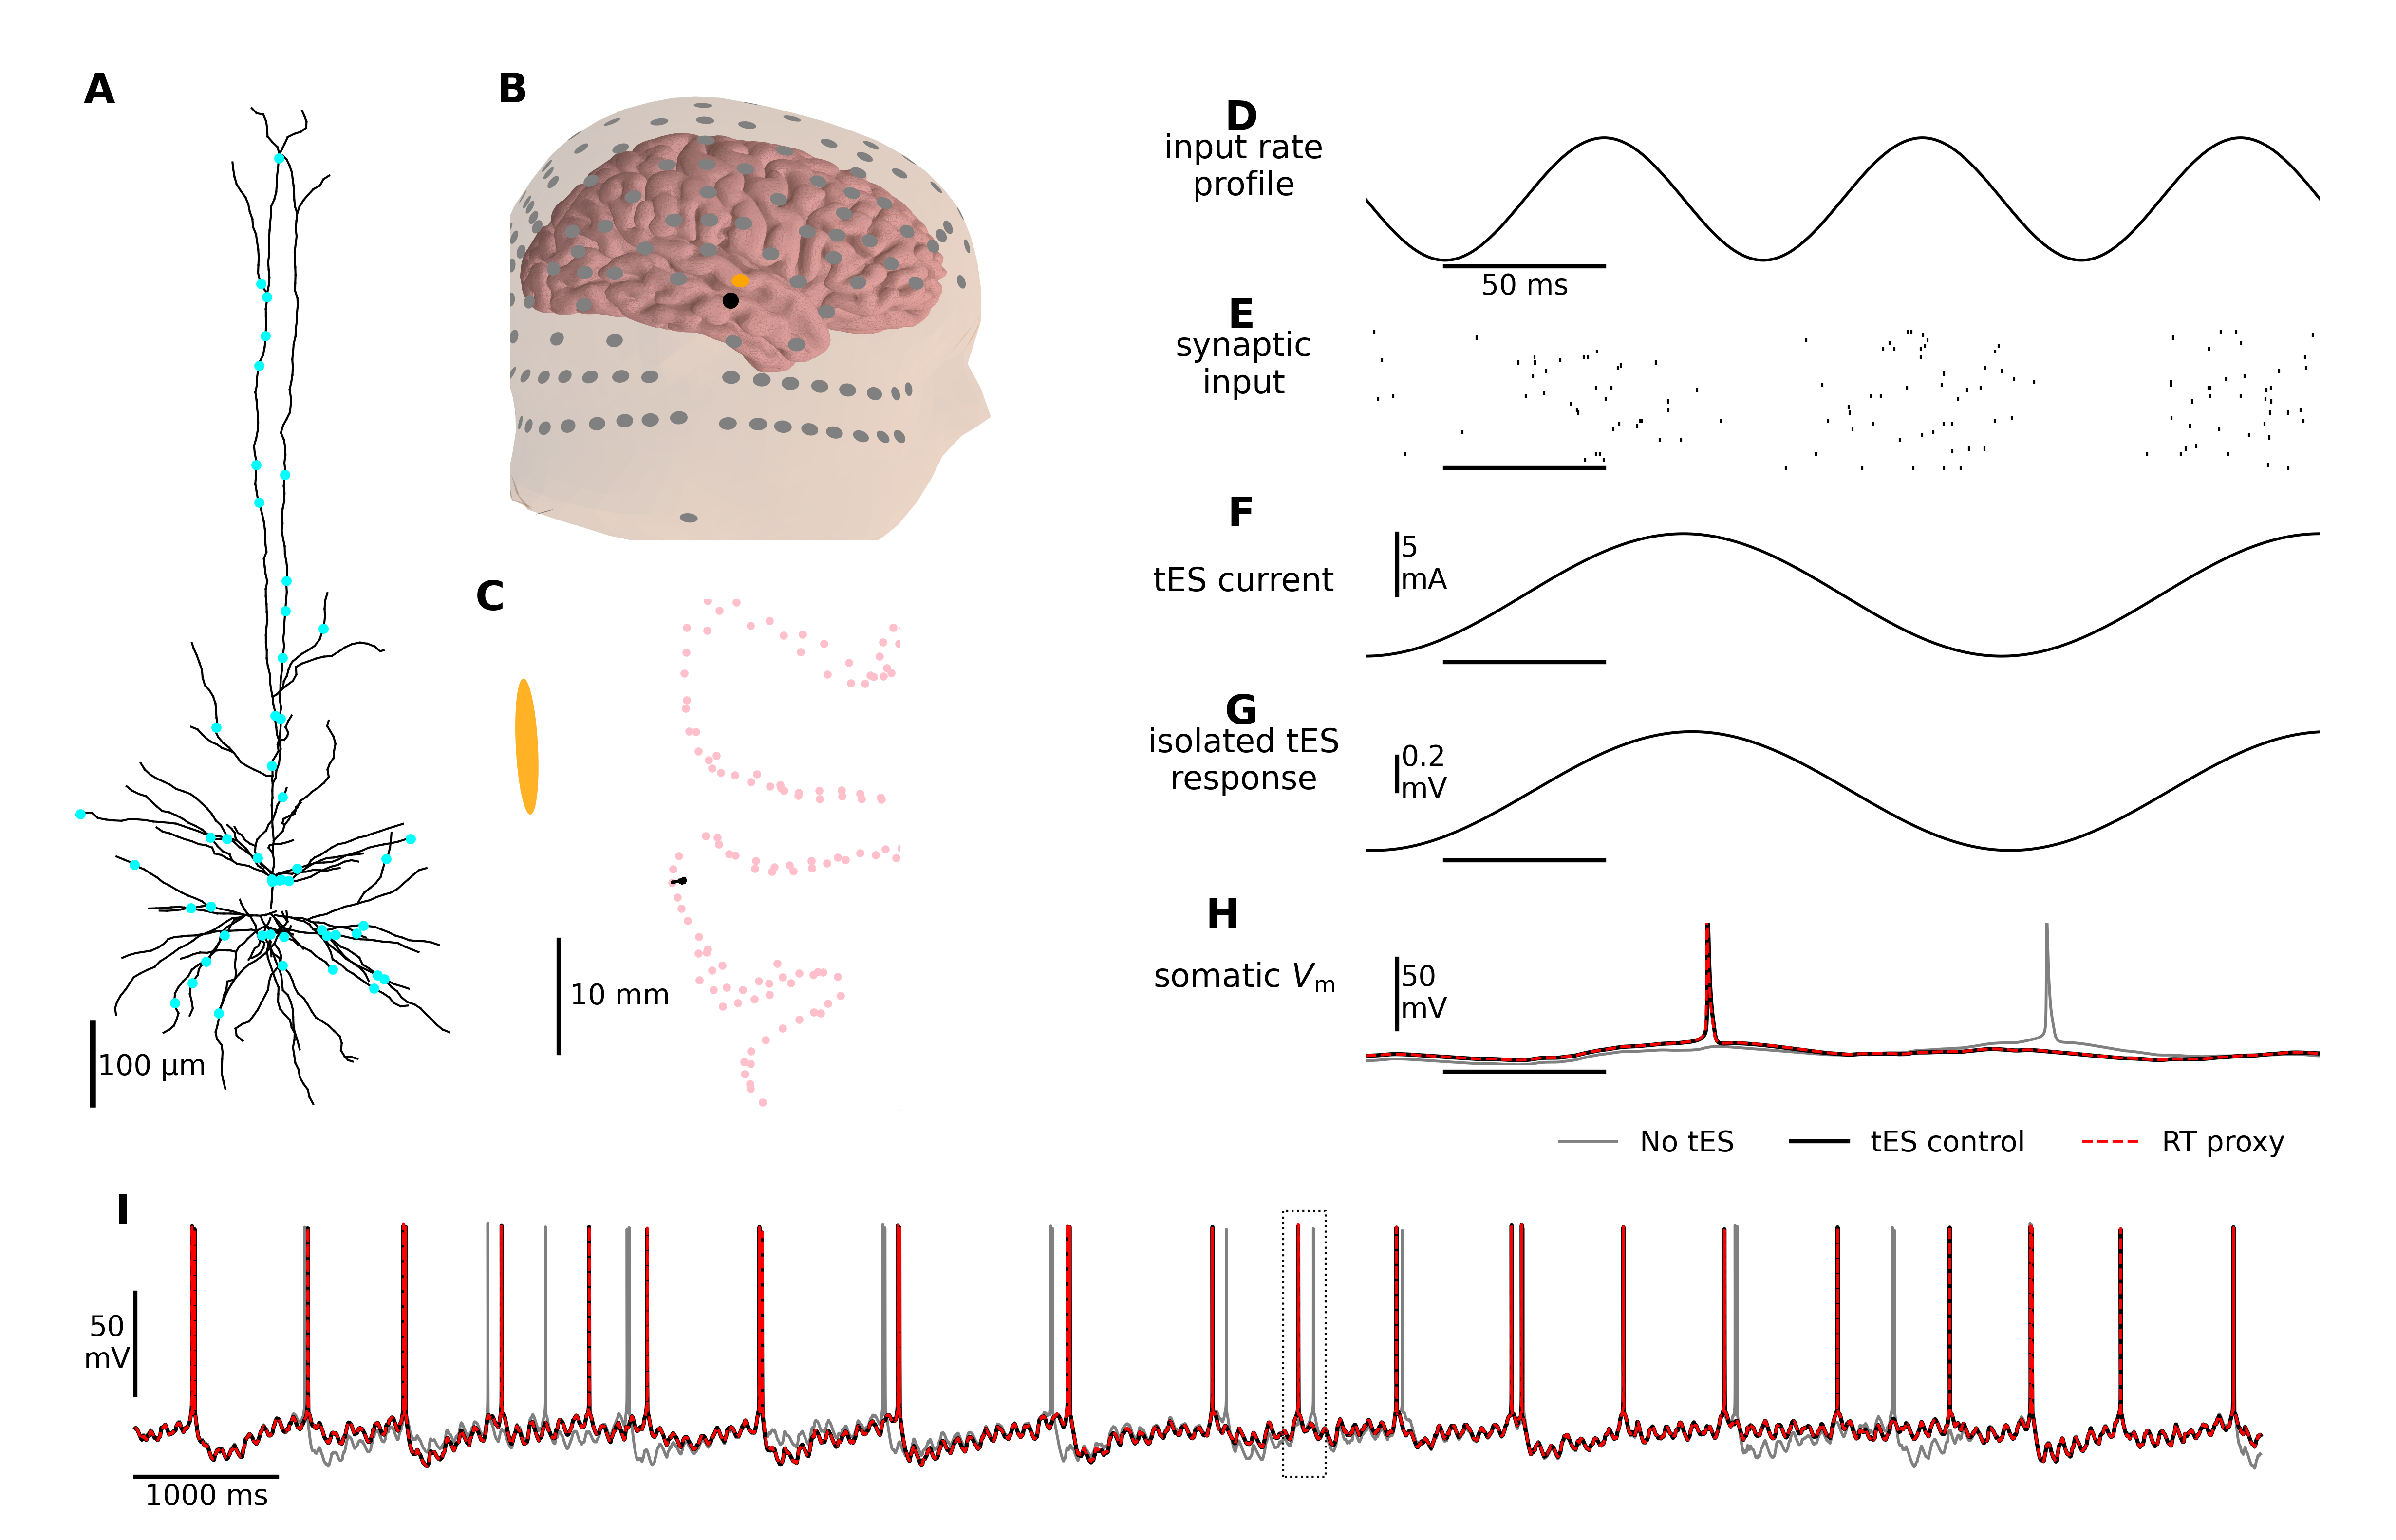

In [166]:

def return_spike_time_idxs(vm):
    """Returns threshold crossings for membrane
    potential of single compartment"""

    crossings = []
    threshold = 0

    if np.max(vm) < threshold:
        return np.array([])
    for t_idx in range(1, len(vm)):
        if vm[t_idx - 1] < threshold <= vm[t_idx]:
            crossings.append(t_idx)

    return np.array(crossings)


spike_idxs_no_tES =  return_spike_time_idxs(somav_ctrl_no_tES)
spike_idxs_tES =  return_spike_time_idxs(somav_ctrl)
spike_idxs_RT_prox =  return_spike_time_idxs(somav_rt_prox)

spike_times_no_tES = tvec_ctrl_no_tES[spike_idxs_no_tES]
spike_times_tES = tvec_ctrl[spike_idxs_tES]
spike_times_RT_prox = tvec_rt_prox[spike_idxs_RT_prox]

time_diffs = []
for spike_time in spike_times_tES:
    time_diffs.append(np.min(np.abs(spike_times_RT_prox - spike_time)))

print("Time differences between control and RT proxy: ", np.array(time_diffs))
print("Mean and STD: ", np.mean(time_diffs), np.std(time_diffs))


t0, t1 = 8100, 8400
#t0, t1 = 000, 14000
plt.close("all")
fig = plt.figure(figsize=[8, 5])
fig.subplots_adjust(hspace=0.4, right=0.98, bottom=0.04, top=0.95, left=0.0,)

# ---- left column: morphology, 3D head, cortical cross-section ----

ax_neur = fig.add_subplot([0.0, 0.25, 0.2, 0.75], aspect=1, frameon=False,
                       xticks=[], yticks=[])

ax_head = fig.add_axes([0.14, 0.67, 0.35, 0.35], projection='3d',
                       facecolor="none", computed_zorder=False, rasterized=True,)
ax_head.set(xlim=[-80, 80], ylim=[-70, 70], zlim=[-70, 70])
ax_head.set_xticks([]); ax_head.set_yticks([]); ax_head.set_zticks([])
ax_geom = fig.add_axes([0.1, 0.28, 0.35, 0.35], aspect=1, frameon=False,
                       xlim=[dipole_loc[0] - 20, dipole_loc[0] + 20],
                       ylim=[dipole_loc[2] - 20, dipole_loc[2] + 25],
                       xticks=[], yticks=[])

# ---- right column: time series (shared time axis) ----
ax_rate = fig.add_subplot(722, frameon=False, xticks=[], yticks=[],)
ax_in = fig.add_subplot(724,frameon=False, xticks=[], yticks=[],)
ax_stim = fig.add_subplot(726,frameon=False, xticks=[], yticks=[],)
ax_tES = fig.add_subplot(728,frameon=False, xticks=[], yticks=[],)
ax_vm_zoom = fig.add_subplot(7,2,10,frameon=False, xticks=[], yticks=[],)

ax_rate.set_ylabel("input rate\nprofile", rotation=0, labelpad=30)
ax_in.set_ylabel("synaptic\ninput", rotation=0, labelpad=30)
ax_stim.set_ylabel("tES current", rotation=0, labelpad=30)
ax_tES.set_ylabel("isolated tES\nresponse", rotation=0, labelpad=30)
ax_vm_zoom.set_ylabel(r"somatic $V_{\rm m}$", rotation=0, labelpad=30)

input_rate_profile = np.cos(2 * np.pi * f_mod * tvec / 1000.0 + 5 * np.pi/2)

ax_rate.plot(tvec, input_rate_profile, 'k', lw=0.7)

#ax_vm_no_tES = fig.add_subplot(333, xlabel="time (ms)", ylabel=r"$V_{\rm m}$ (mV)", #ylim=[-15, 1]
                     # )
ax_vm_tES = fig.add_axes([0.0, .02, 1, 0.2], frameon=False, xticks=[], yticks=[],
                            #xlabel="time (ms)", ylabel=r"$V_{\rm m}$ (mV)", #ylim=[-15, 1]
                     )
# ax_vm_RT_prox= fig.add_subplot(339, xlabel="time (ms)", ylabel=r"$V_{\rm m}$ (mV)", #ylim=[-15, 1]
#                      )

# --- A: morphology + synapse locations ---
cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, cutoff=cutoff,
                     make_passive=True)
ax_neur.plot(cell.x.T, cell.z.T, c='k', lw=0.5, zorder=1)
ax_neur.plot(cell.x[syn_idxs].mean(axis=1), cell.z[syn_idxs].mean(axis=1), 'o', c='cyan', ms=2.5, mec='none', zorder=2)

ax_neur.plot([cell.x.min() + 20, cell.x.min() + 20], [cell.z.min(), cell.z.min() + 100],
             c='k', lw=1.5)
ax_neur.text(cell.x.min() + 26, cell.x.min() + 50, "100 µm", va='center', fontsize=7)
del cell

ax_vm_tES.plot([0, 0], [-50, 0], lw=1, c='k')
ax_vm_tES.text(-200, -25, "50\nmV", va='center', ha="center", fontsize=7)

ax_vm_tES.plot([0, 1000], [-90, -90], lw=1, c='k')
ax_vm_tES.text(500, -100, "1000 ms", va='center', ha="center", fontsize=7)

ax_rate.plot([t0 + 25, t0 + 75], [-1.1, -1.1], lw=1, c='k')
ax_rate.text(t0 + 50, -1.2, "50 ms", va='top', ha="center", fontsize=7)

ax_in.plot([t0 + 25, t0 + 75], [0, 0], lw=1, c='k')
#ax_in.text(t0 + 50, -2, "100 ms", va='top', ha="center", fontsize=7)

ax_stim.plot([t0 + 25, t0 + 75], [-5.5, -5.5], lw=1, c='k')
#ax_stim.text(t0 + 50, -6, "100 ms", va='top', ha="center", fontsize=7)

ax_tES.plot([t0 + 25, t0 + 75], [-0.4, -0.4], lw=1, c='k')
#ax_tES.text(t0 + 50, -0.45, "100 ms", va='center', ha="center", fontsize=7)

ax_vm_zoom.plot([t0 + 25, t0 + 75], [-80, -80], lw=1, c='k', clip_on=False)
#ax_vm_zoom.text(t0 + 50, -110, "100 ms", va='center', ha="center", fontsize=7)


ax_stim.plot([t0+10, t0+10], [0., 5], lw=1, c='k')
ax_stim.text(t0+11, 2.5, "5\nmA", va='center', ha="left", fontsize=7)

ax_tES.plot([t0+10, t0+10], [0., 0.2], lw=1, c='k')
ax_tES.text(t0+11, 0.1, "0.2\nmV", va='center', ha="left", fontsize=7)

ax_vm_zoom.plot([t0+10, t0+10], [-50, 0], lw=1, c='k')
ax_vm_zoom.text(t0+11, -25, "50\nmV", va='center', ha="left", fontsize=7)

ax_geom.plot([dipole_loc[0] -10, dipole_loc[0] -10], [dipole_loc[2] -15, dipole_loc[2] -5], c='k', lw=1)
ax_geom.text(dipole_loc[0] - 9, dipole_loc[2] -10, "10 mm", ha='left', va="center", fontsize=7)

# --- E: 3D head, left-lateral view, MTG source marked ---
ax_head.plot_trisurf(x_ctx, y_ctx, z_ctx, triangles=cortex_tri, color="pink", zorder=0)
ax_head.plot_trisurf(x_h, y_h, z_h, triangles=head_tri, color="#c87137",
                     zorder=0, alpha=0.15)
upper_idxs = np.where(elecs[0, :] < 0)[0]
for elec_idx in upper_idxs:

    fc = 'orange' if elec_idx == eeg_elec_idx else 'gray'
    disc = Circle((0, 0), 4, facecolor=fc, zorder=-elecs[0, elec_idx], edgecolor='k', lw=0.0,)
    ax_head.add_patch(disc)
    pathpatch_2d_to_3d(disc, z=0, normal=elecs[3:, elec_idx])
    pathpatch_translate(disc, elecs[:3, elec_idx])
_marker = cortex[:, vertex_idx].copy(); _marker[0] -= 18   # push out toward viewer
ax_head.plot([_marker[0]], [_marker[1]], [_marker[2]], 'o', c='k', ms=3, zorder=1e4)
ax_head.view_init(elev=0, azim=0)
ax_head.axis('off')

# --- F: cortical cross-section through the source, with source arrow ---
threshold = 1.5
xz_plane_idxs = np.where(np.abs(cortex[1, :] - dipole_loc[1]) < threshold)[0]
ax_geom.scatter(cortex[0, xz_plane_idxs], cortex[2, xz_plane_idxs], s=1, c='pink')
#ax_geom.plot(cortex[0, vertex_idx], cortex[2, vertex_idx], 'o', c='red', ms=5)

# The cell was already rotated onto the surface normal before simulation, so plot
# its compartments directly. Translate so the apical tip (most-outward point along
# the normal) sits at the cortical vertex, with the cell hanging inward.
cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, cutoff=cutoff,
                     make_passive=True, rotation=rotation)
_ctr = np.array([cell.x.mean(1), cell.y.mean(1), cell.z.mean(1)])
_tip = _ctr[:, np.argmax(_ctr.T @ nyhead.cortex_normal_vec)]
ax_geom.plot((cell.x - _tip[0]).T / 1000 + cortex[0, vertex_idx],
             (cell.z - _tip[2]).T / 1000 + cortex[2, vertex_idx], c='k', lw=0.5, zorder=1)

# EEG electrode (top_elec_idx) as its flat disc projected onto the x-z plane,
# so the oval reflects the electrode's orientation.
def elec_oval(pos, normal, r=6., npts=60):
    n = normal / np.linalg.norm(normal)
    ref = np.array([0, 0, 1.]) if abs(n[2]) < 0.9 else np.array([0, 1., 0])
    u = np.cross(n, ref); u /= np.linalg.norm(u)
    v = np.cross(n, u)
    th = np.linspace(0, 2 * np.pi, npts)
    return pos[:, None] + r * np.cos(th) * u[:, None] + r * np.sin(th) * v[:, None]

_ep = elec_oval(elecs[:3, eeg_elec_idx], elecs[3:, eeg_elec_idx], r=6.)
ax_geom.fill(_ep[0], _ep[2], facecolor='orange', edgecolor='k', lw=0,
             alpha=0.85, zorder=4)

#ax_geom.plot(cell_x.T / 1000 + cortex[0, vertex_idx], cell_z.T / 1000 + cortex[2, vertex_idx], c='k', lw=0.5, zorder=1)


# --- B: presynaptic input raster (shows 20 Hz modulation) ---

ax_in.eventplot([st for st in syn_spike_times], colors='k', lineoffsets=np.arange(num_syns),
                linelengths=1.5, linewidths=0.5)
ax_in.set_ylim(-1, num_syns)
ax_in.set_xlim(t0, t1)


# --- C: somatic membrane potential with APs ---
l1, = ax_vm_tES.plot(tvec_ctrl_no_tES, somav_ctrl_no_tES, 'gray', lw=0.7)
l2, = ax_vm_tES.plot(tvec_ctrl, somav_ctrl , 'k', lw=1.)
l3, = ax_vm_tES.plot(tvec_rt_prox, somav_rt_prox, '--', c='r', lw=0.7)

mask = (t0<tvec_ctrl_no_tES) & (tvec_ctrl_no_tES<t1)
l1, = ax_vm_zoom.plot(tvec_ctrl_no_tES[mask], somav_ctrl_no_tES[mask] , 'gray', lw=0.7)
l2, = ax_vm_zoom.plot(tvec_ctrl[mask], somav_ctrl[mask] , 'k', lw=1.)
l3, = ax_vm_zoom.plot(tvec_rt_prox[mask], somav_rt_prox[mask], '--', c='r', lw=0.7)


ax_tES.plot(tvec_rt_prox[mask], (rt_based_dVm - np.mean(rt_based_dVm))[mask], '-', c='k', lw=0.7)
ax_tES.set_xlim(t0, t1)

ax_vm_tES.legend([l1, l2, l3], ["No tES", "tES control", "RT proxy"],
             loc=(0.65, 1.1), fontsize=7, frameon=False, ncol=3)

ax_vm_tES.plot([t0, t0, t1, t1, t0], [-90, 40, 40, -90, -90], c='k', lw=0.5, ls=':', clip_on=False)

#error = somav_ctrl - np.mean(somav_ctrl) - (somav_rt_prox - np.mean(somav_rt_prox))
#rel_error = np.std( somav_ctrl - somav_rt_prox) / np.std(somav_ctrl)

#print(f"Mean absolute error: {np.mean(np.abs(error))}; Relative error: {rel_error}")

#ax_vm.plot(ap_times, np.full_like(ap_times, 30), 'r.', ms=4)
ax_rate.set_xlim(t0, t1)
ax_vm_zoom.set_xlim(t0, t1)
ax_vm_zoom.set_ylim(-75, 25)

#ax_vm_no_tES.set_xlim(t0, t1)
#ax_vm_RT_prox.set_xlim(t0, t1)

# --- D: current dipole moment (P_z) ---
ax_stim.plot(tvec_ctrl[mask], tES_current[-len(tvec_ctrl):][mask] * 1e-6, 'k', lw=0.7)
ax_stim.set_xlim(t0, t1)

# --- G: EEG at the closest electrode ---
# ax_eeg.plot(tvec, eeg[eeg_elec_idx], 'k', lw=0.7)
# ax_eeg.set_xlim(0, tstop)

# mark the modulation peaks on all time-series panels
#for ax in [ax_in, ax_vm, ax_stim]:
#    for pt in peak_times:
 #       ax.axvline(pt, ls='--', c='0.7', lw=0.4, zorder=0)

mark_subplots([ax_neur], "A", ypos=0.97, xpos=0.1)
fig.text(0.2, 0.97, "B", fontweight='demibold', fontsize=10)
mark_subplots([ax_geom], "C", ypos=1.0, xpos=0.1)
mark_subplots([ax_rate], "D", ypos=1.09, xpos=-0.13)
mark_subplots([ax_in], "E", ypos=1.09, xpos=-0.13)
mark_subplots([ax_stim], "F", ypos=1.09, xpos=-0.13)
mark_subplots([ax_tES], "G", ypos=1.09, xpos=-0.13)
mark_subplots([ax_vm_tES], "I", ypos=0.95, xpos=0.04)

mark_subplots([ax_vm_zoom], "H", ypos=1.05, xpos=-0.15)

# mark_subplots([ax_vm_no_tES], "C", ypos=1.05, xpos=-0.13)
# mark_subplots([ax_vm_tES], "F", ypos=1.05, xpos=-0.13)
# mark_subplots([ax_vm_RT_prox], "H", ypos=1.05, xpos=-0.13)
# mark_subplots([ax_tES], "G", ypos=1.07, xpos=-0.13)
# mark_subplots([ax_stim], "E", ypos=1.07, xpos=-0.13)
# mark_subplots([ax_p], "D", ypos=1.05, xpos=-0.13)
#mark_subplots([ax_eeg], "G", ypos=1.05, xpos=-0.13)
simplify_axes([ax_in, ax_vm_tES, ax_stim, ax_tES])#, ax_p, ax_eeg])

plt.savefig(f"ongoing_input_mtg_active_{cell_name}_{make_passive}.png")
plt.savefig(f"fig12_R1_wider_window.pdf")

# plt.close("all")
#
# fig = plt.figure(figsize=[12, 5])
# fig.subplots_adjust(hspace=0.4, right=0.98, bottom=0.1, top=0.95, left=0.1,)
# ax1 = fig.add_subplot(111, xlabel="time (ms)", ylabel=r"$V_{\rm m}$ (mV)",)
# l1, = ax1.plot(tvec_ctrl, somav_ctrl - np.mean(somav_ctrl), 'k', lw=1)
# l2, = ax1.plot(tvec_ctrl_no_tES, somav_ctrl_no_tES - np.mean(somav_ctrl_no_tES), 'gray', lw=0.8)
# l3, = ax1.plot(tvec_rt_prox, (somav_rt_prox - np.mean(somav_rt_prox)), '-', c='r', lw=0.6)
# ax1.legend([l1, l2, l3], ["tES control", "No tES", "RT proxy"],
#              loc=(0.55, .95), fontsize=7, frameon=False, ncol=3)
# simplify_axes(ax1)
#
# plt.savefig("full_time_vmems.pdf")

Time differences between control and RT proxy:  [0.0625 0.1875 0.125  0.     0.125  0.125  0.375  0.625  0.125  2.8125
 0.625  0.875  4.125  0.8125 0.375  0.1875 0.1875 0.0625 0.125  0.125
 0.125  0.0625 0.125  0.1875 0.0625 0.75   0.0625]
Mean and STD:  0.4976851851851852 0.8938902508257164


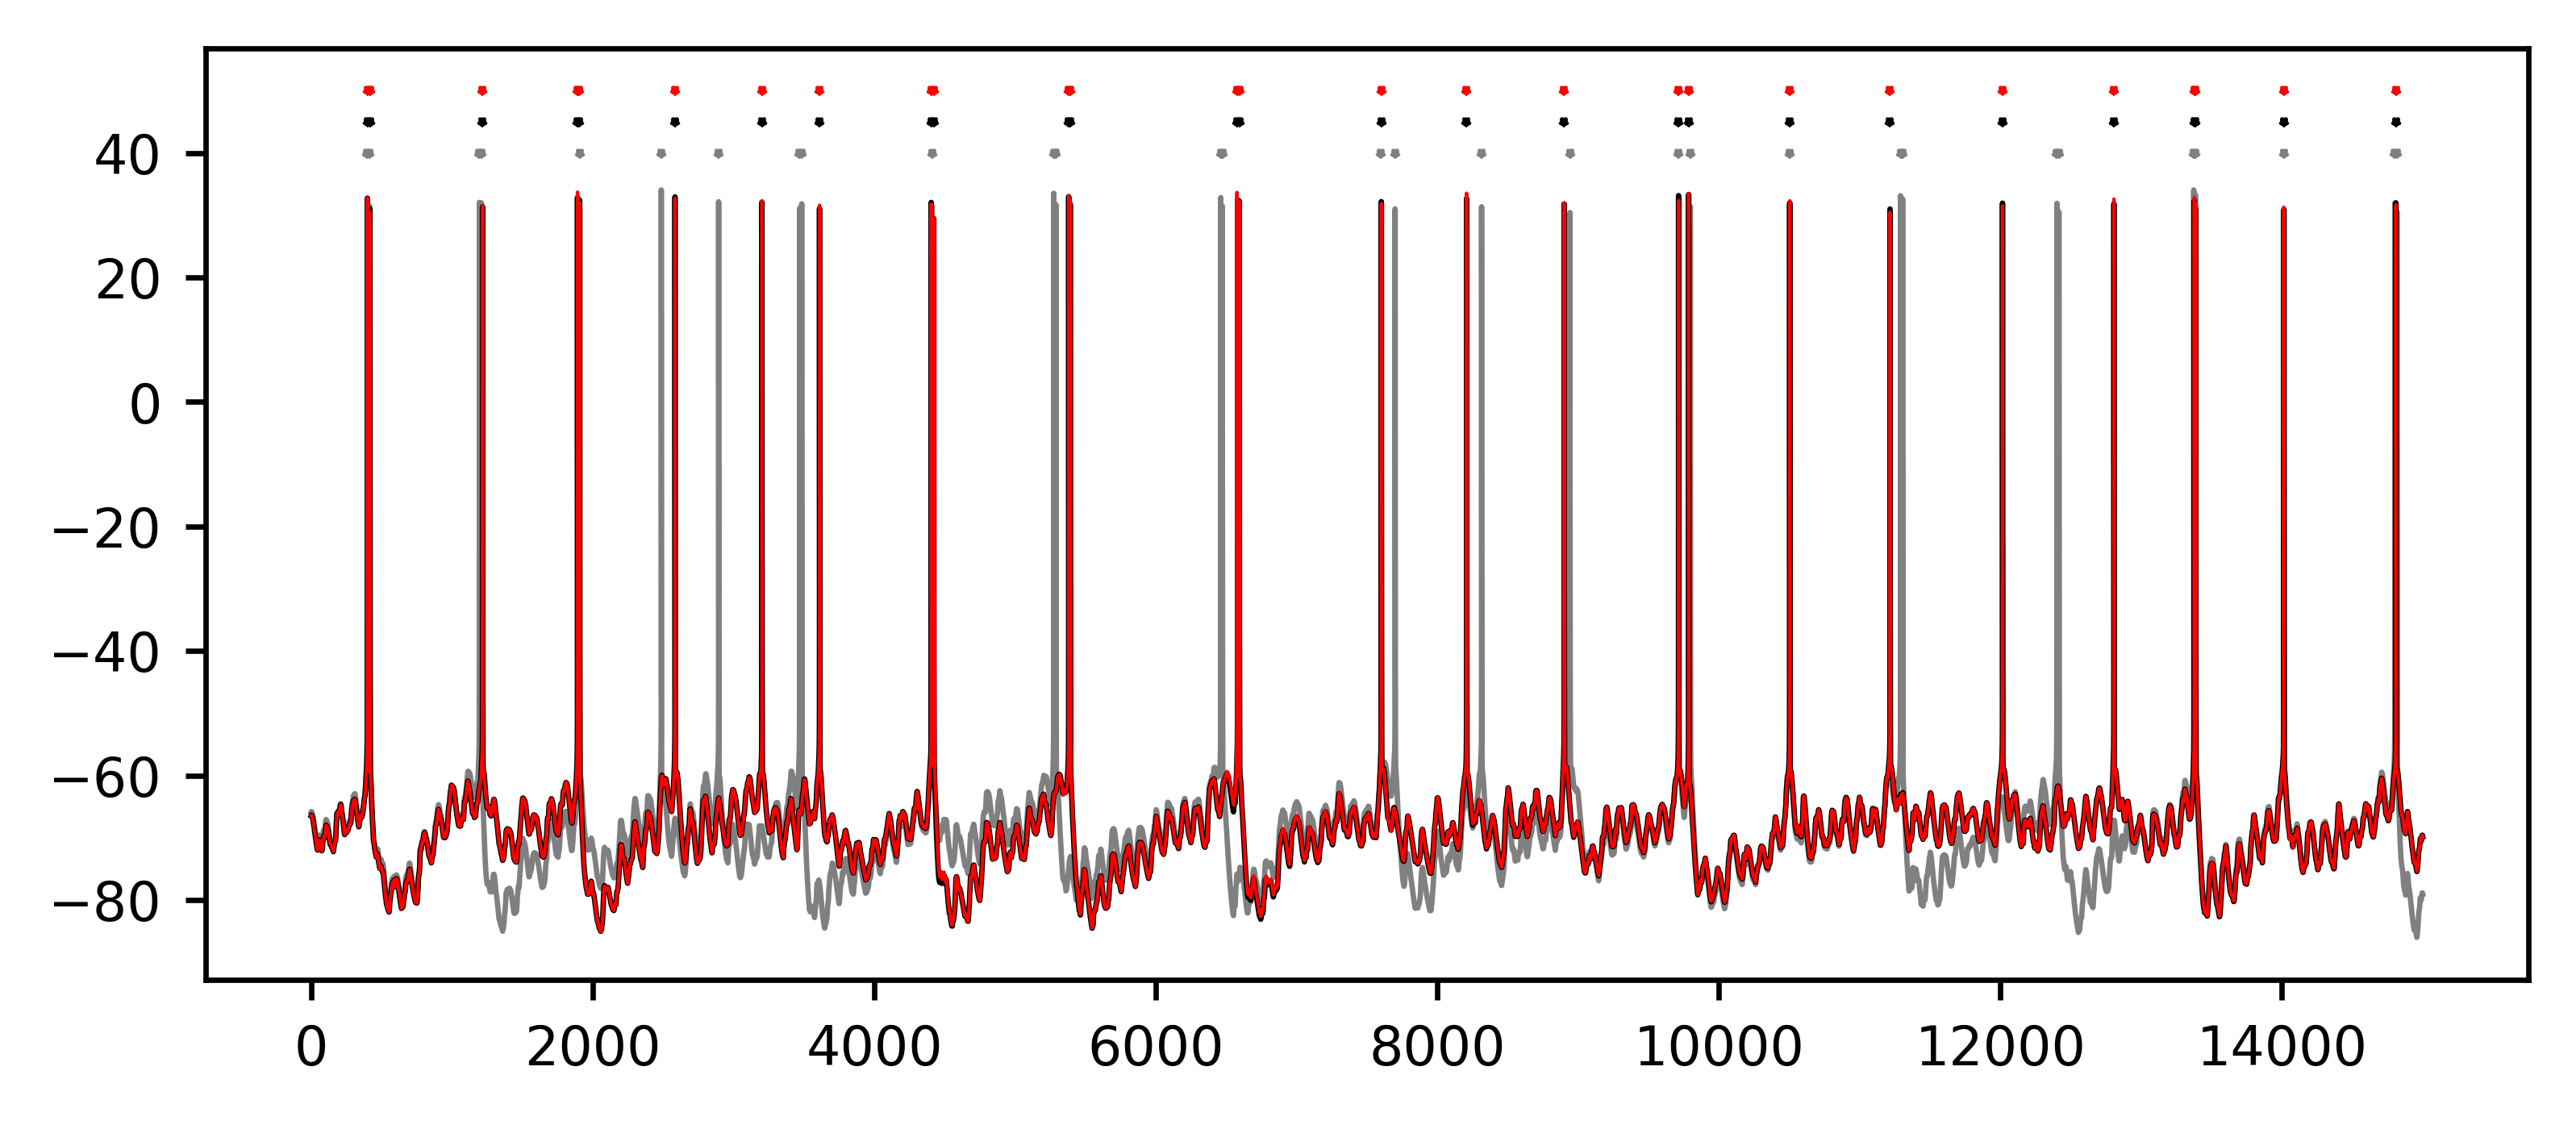

In [63]:

plt.plot(tvec_ctrl_no_tES, somav_ctrl_no_tES, 'gray', lw=0.8)
plt.plot(tvec_ctrl, somav_ctrl, 'k', lw=0.8)
plt.plot(tvec_rt_prox, somav_rt_prox, 'r', lw=0.5)

plt.plot(tvec_ctrl_no_tES[spike_idxs_no_tES], np.ones(len(spike_idxs_no_tES)) * 40, '*', ms=1, c='gray')
plt.plot(tvec_ctrl[spike_idxs_tES], np.ones(len(spike_idxs_tES)) * 45, '*', ms=1, c='k')
plt.plot(tvec_rt_prox[spike_idxs_RT_prox], np.ones(len(spike_idxs_RT_prox)) * 50, '*', ms=1, c='r')

# plt.xlim(0, 2590)


NameError: name 'm' is not defined

In [148]:
nyhead.lead_field[:, vertex_idx, eeg_elec_idx]

array([-0.43524551,  0.15438229, -0.05691778])

In [150]:
print(tES_field)
print(nyhead.cortex_normal_vec)

[-0.43524551  0.15438229 -0.05691778]
[-0.98645608  0.02831362 -0.16156343]


(0.0, 5000.0)

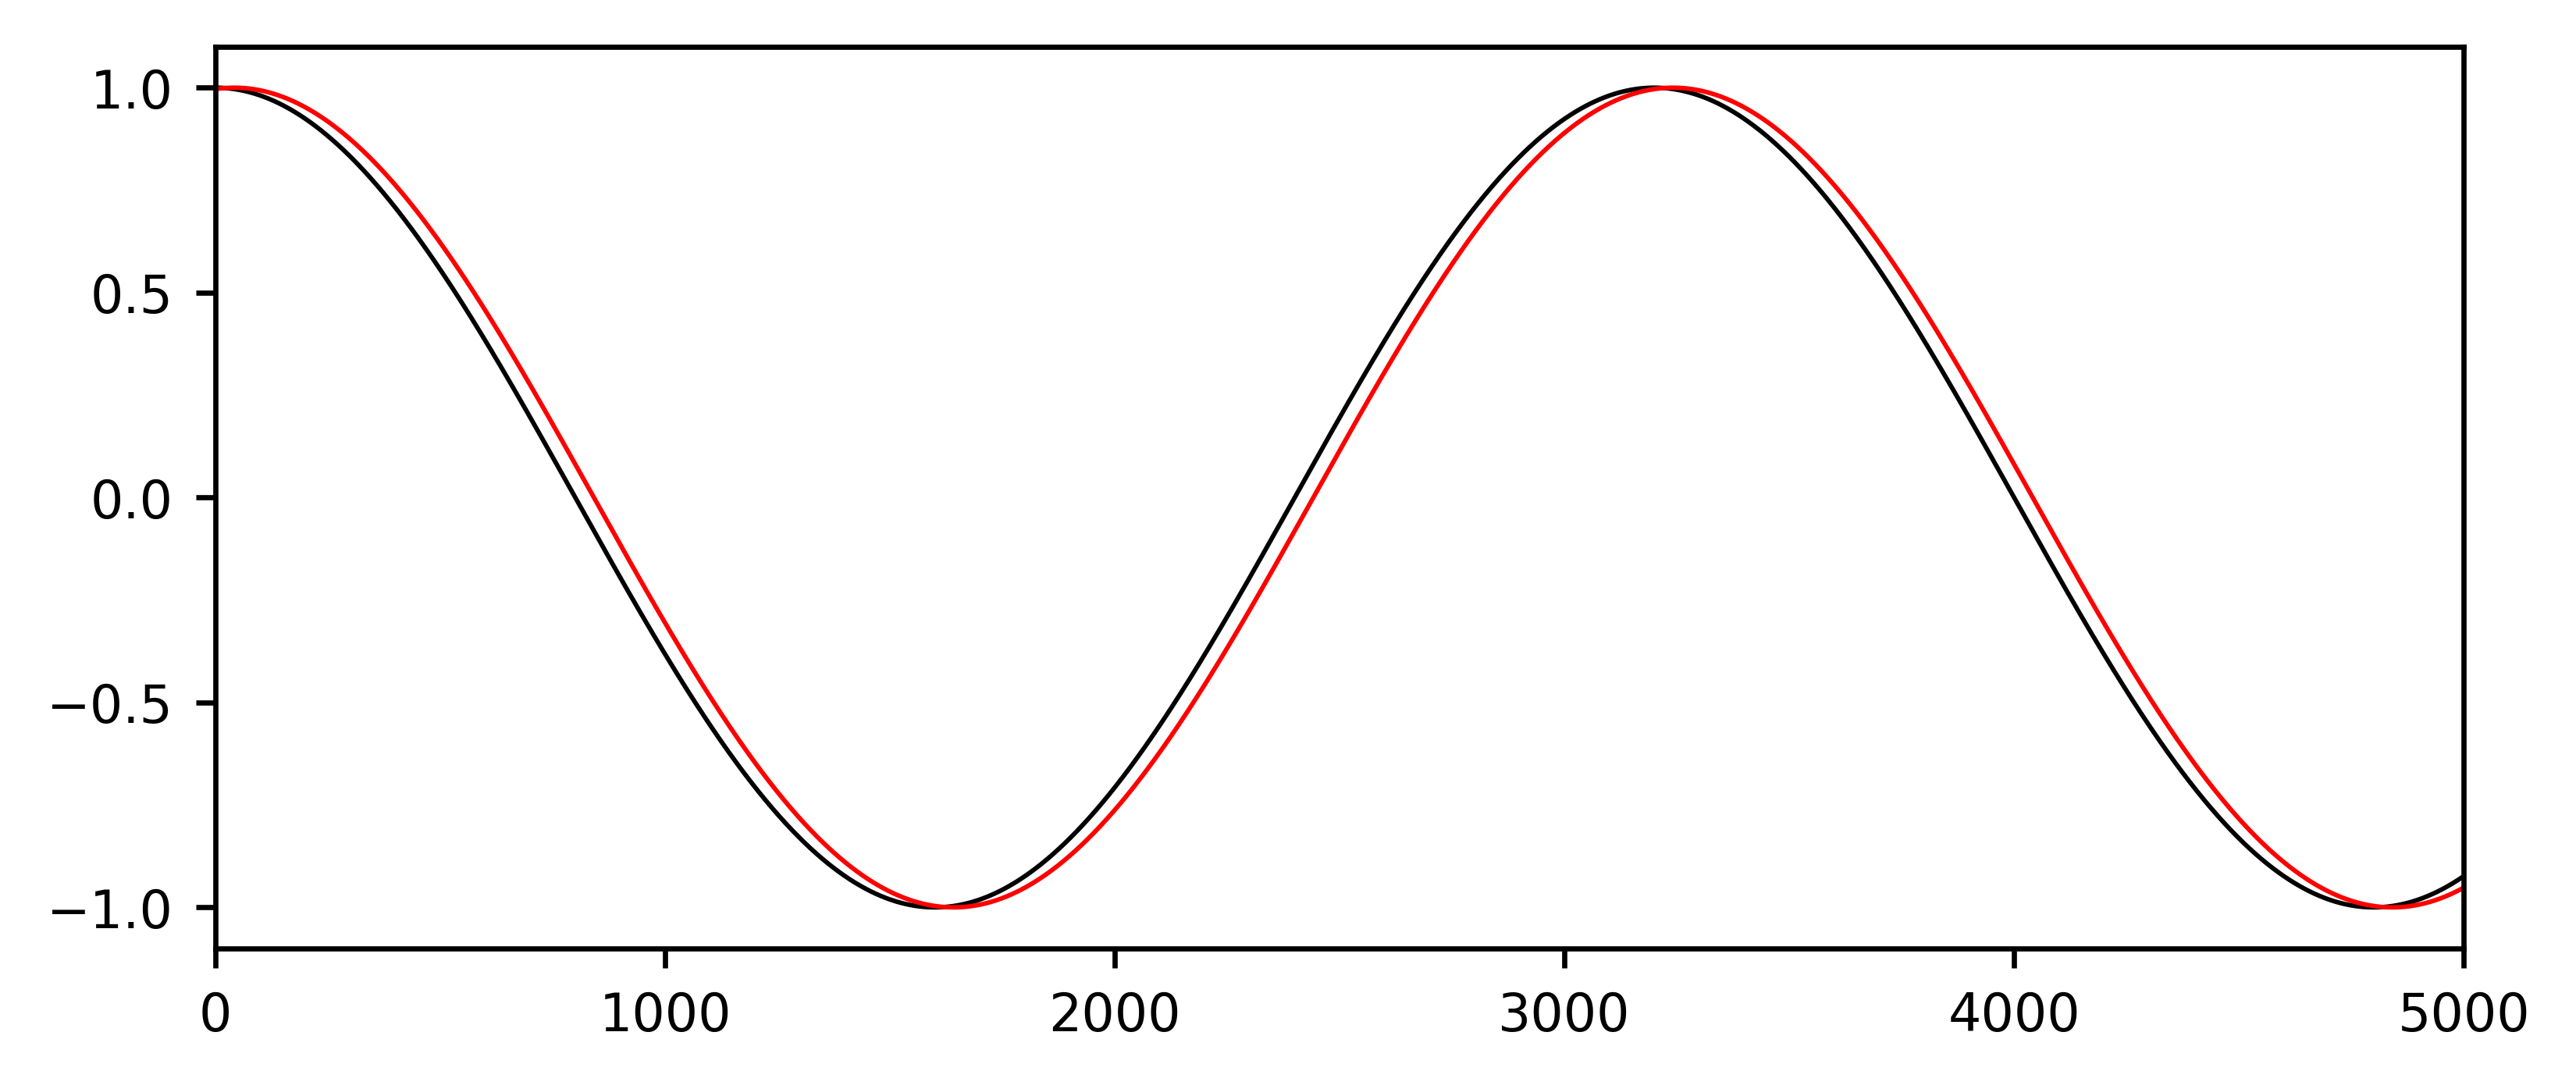

In [155]:
plt.plot(tES_current / np.max(tES_current), 'k', lw=0.7)
plt.plot(rt_based_dVm / np.max(rt_based_dVm), 'r', lw=0.7)
plt.xlim(0, 5000)

In [152]:
rt_based_dVm

array([0.34202643, 0.3420805 , 0.34213324, ..., 0.34185633, 0.34191435,
       0.34197105], shape=(240000,))